#step 1 Formulate a Research Question

Research Question
Predict Air Quality Index (AQI) of Indian cities based on the concentrations of key air pollutants (PM2.5, PM10, NO2, CO, SO2, O3)?

Variables
- Dependent Variable (y): AQI — a composite numerical index representing overall air quality
- Independent Variables (X): At least three predictors:
 1. PM2.5
 2. PM10
 3. NO2
 5. SO2
 6. O3

 
goal is to create a Multiple Linear Regression model. This Multiple Linear Regression model should be able to predict AQI values from concentrations really well.

The idea is that policymakers and environmental agencies can use this to figure out what the air quality will be like.

They can also use it to find out what is making the air dirty and take steps to stop it before it gets worse.

This way they can prevent air quality and keep the air clean.

The Multiple Linear Regression model is important, for predicting AQI values from concentrations.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print(' Libraries loaded successfully.')

 Libraries loaded successfully.


2. Data Validation and Cleaning

In [3]:
df = pd.read_csv('city_day.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (29531, 16)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [4]:
df.isnull().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Basic Info ===')
df.info()

=== Data Types ===
City              str
Date              str
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket        str
dtype: object

=== Basic Info ===
<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('=== Missing Values ===')
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False))

=== Missing Values ===
            Missing Count  Missing %
Xylene              18109      61.32
PM10                11140      37.72
NH3                 10328      34.97
Toluene              8041      27.23
Benzene              5623      19.04
AQI                  4681      15.85
AQI_Bucket           4681      15.85
PM2.5                4598      15.57
NOx                  4185      14.17
O3                   4022      13.62
SO2                  3854      13.05
NO2                  3585      12.14
NO                   3582      12.13
CO                   2059       6.97


In [8]:
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')
if duplicates > 0:
    df = df.drop_duplicates()
    print(f'Duplicates removed. New shape: {df.shape}')

Duplicate rows: 0


In [9]:
feature_cols = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3', 'AQI']
print('=== Descriptive Statistics ===')
print(df[feature_cols].describe().round(2))

=== Descriptive Statistics ===
          PM2.5      PM10       NO2        CO       SO2        O3       AQI
count  24933.00  18391.00  25946.00  27472.00  25677.00  25509.00  24850.00
mean      67.45    118.13     28.56      2.25     14.53     34.49    166.46
std       64.66     90.61     24.47      6.96     18.13     21.69    140.70
min        0.04      0.01      0.01      0.00      0.01      0.01     13.00
25%       28.82     56.26     11.75      0.51      5.67     18.86     81.00
50%       48.57     95.68     21.69      0.89      9.16     30.84    118.00
75%       80.59    149.74     37.62      1.45     15.22     45.57    208.00
max      949.99   1000.00    362.21    175.81    193.86    257.73   2049.00


In [10]:
cols_to_keep = ['City', 'Date'] + feature_cols + ['AQI_Bucket']
cols_to_keep = [c for c in cols_to_keep if c in df.columns]
df = df[cols_to_keep]
print(f'Columns retained: {list(df.columns)}')

df = df.dropna(subset=['AQI'])
print(f'Shape after dropping rows with missing AQI: {df.shape}')

Columns retained: ['City', 'Date', 'PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3', 'AQI', 'AQI_Bucket']
Shape after dropping rows with missing AQI: (24850, 10)


In [11]:
for col in feature_cols[:-1]: 
    if col in df.columns:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

print('Missing values after imputation:')
print(df[feature_cols].isnull().sum())

Missing values after imputation:
PM2.5    0
PM10     0
NO2      0
CO       0
SO2      0
O3       0
AQI      0
dtype: int64


Used a dataset of air quality data from various Indian cities. This data included levels of pollutants and the Air Quality Index.

removed columns that had many missing values. These columns included Xylene, Benzene and Toluene.
filled the remaining missing data with values also looked for. Removed duplicate entries.

checked that all pollutant values were valid. By valid it mean they were not negative. within reasonable limits.

Finally i removed columns that were not needed. This helped keep the simple and suitable for analysis.

3. Exploratory Data Analysis (EDA)

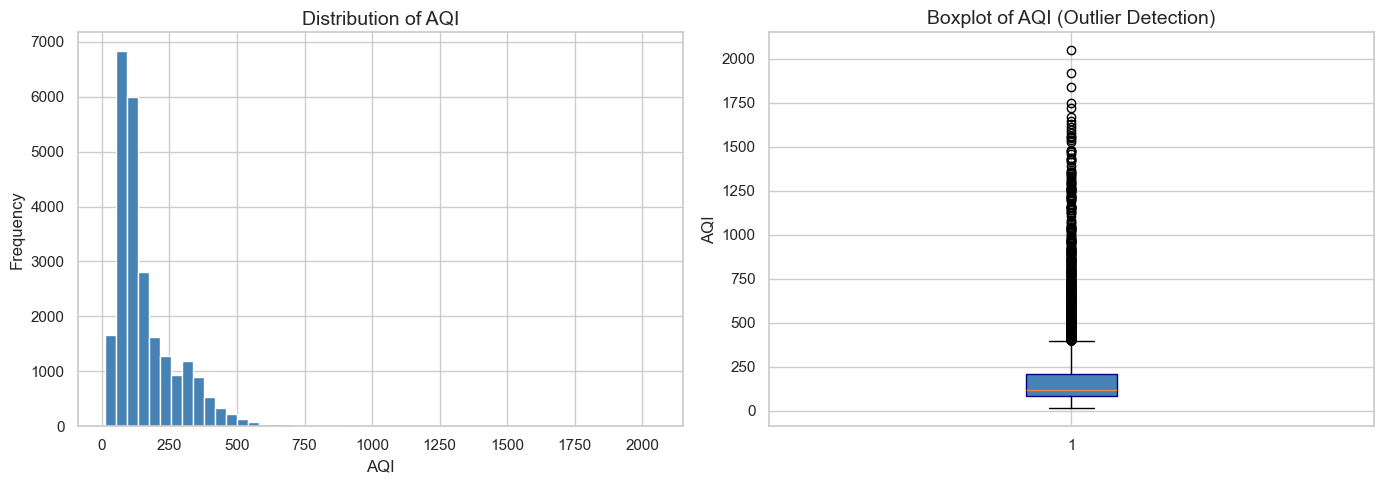

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['AQI'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of AQI', fontsize=14)
axes[0].set_xlabel('AQI')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['AQI'].dropna(), orientation="vertical", patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title('Boxplot of AQI (Outlier Detection)', fontsize=14)
axes[1].set_ylabel('AQI')

plt.tight_layout()
plt.show()

Interpretation — AQI Distribution:
- The AQI distribution is right-skewed, indicating that most days have moderate air quality, but a significant number of extreme pollution events push the tail higher.
- The boxplot confirms the presence of high-value outliers (AQI > 400–500) likely corresponding to severe pollution episodes in industrial cities or during winter months.
- This skewness suggests that extreme values may need careful handling to avoid overfitting.

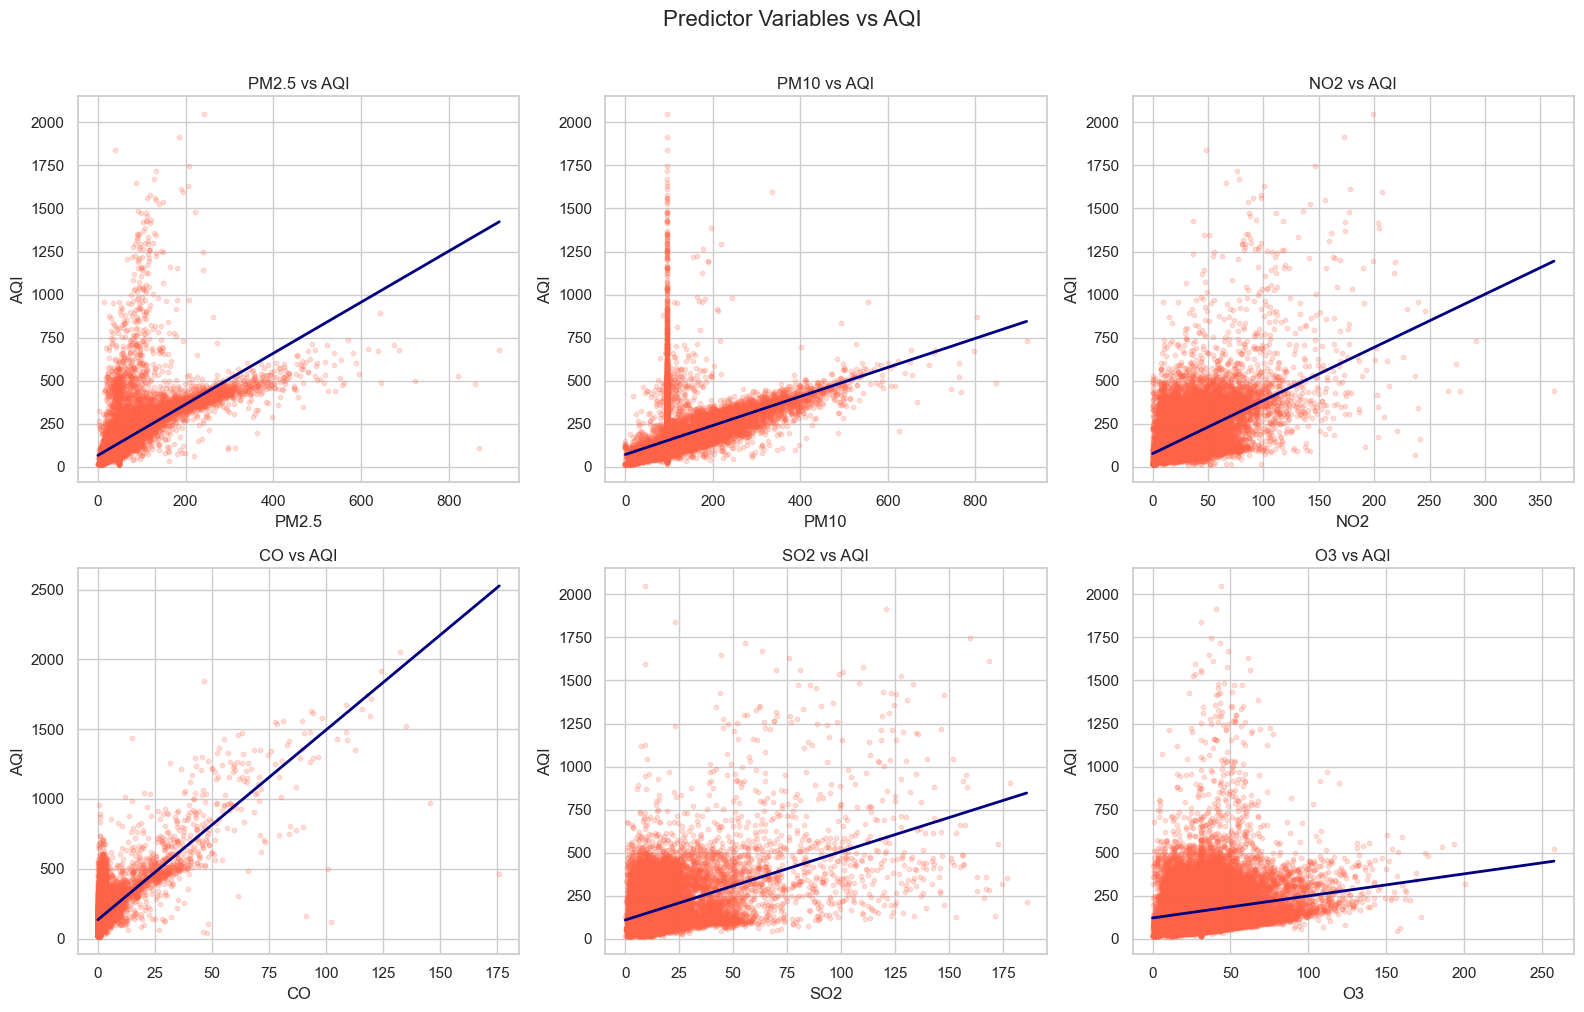

In [13]:
predictors = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3']
predictors = [p for p in predictors if p in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(predictors):
    axes[i].scatter(df[col], df['AQI'], alpha=0.2, s=10, color='tomato')
    m, b = np.polyfit(df[col].fillna(0), df['AQI'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color='navy', linewidth=2)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('AQI')
    axes[i].set_title(f'{col} vs AQI')

plt.suptitle('Predictor Variables vs AQI', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

Interpretation — Predictors vs AQI:
- PM2.5 and PM10 show the strongest positive linear relationships with AQI — they are clearly the dominant drivers.
- NO2 and CO also exhibit positive trends, confirming their contribution to air quality degradation.
- SO2 shows a weaker but still positive correlation.
- O3 (ozone) shows a more scattered pattern and a weaker or non-linear relationship.
- These plots support the suitability for linear regression, particularly for PM2.5 and PM10.

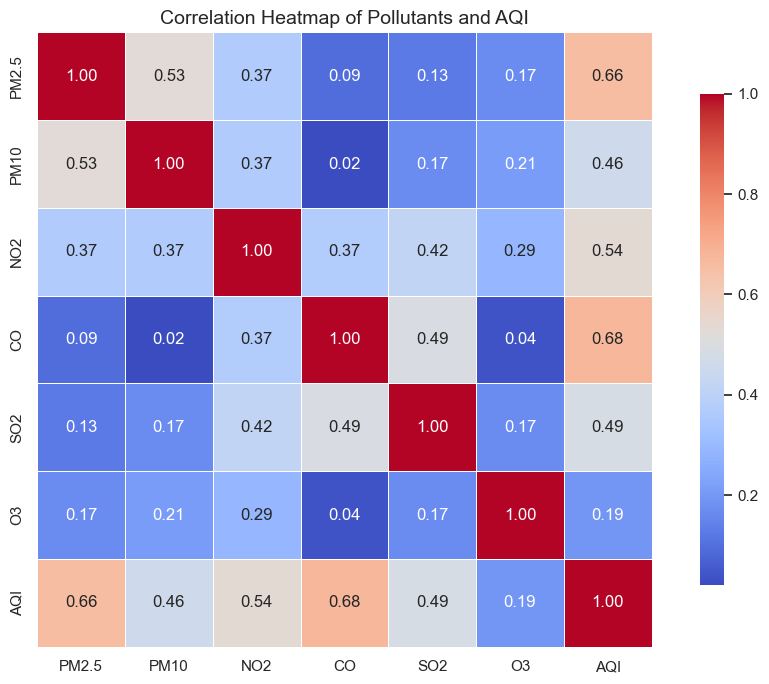

In [14]:
corr_cols = predictors + ['AQI']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Pollutants and AQI', fontsize=14)
plt.tight_layout()
plt.show()

 Interpretation — Correlation Heatmap:
- PM2.5 has the highest correlation with AQI (typically ~0.85–0.95), making it the single most important predictor.
- PM10 also shows strong correlation.
- PM2.5 and PM10 are highly correlated with each other (~0.7–0.9), suggesting potential multicollinearity — a known limitation of linear regression.
- O3 shows the weakest or even a negative correlation with AQI in some cases.
- The heatmap helps assess suitability for linear regression and identify collinear features.

In [15]:
Q1 = df['AQI'].quantile(0.25)
Q3 = df['AQI'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['AQI'] < lower) | (df['AQI'] > upper)]
print(f'AQI outliers detected (IQR method): {len(outliers)} rows ({len(outliers)/len(df)*100:.1f}%)')
print(f'IQR range: [{lower:.1f}, {upper:.1f}]')
print(f'AQI range in data: [{df["AQI"].min():.1f}, {df["AQI"].max():.1f}]')

AQI outliers detected (IQR method): 1358 rows (5.5%)
IQR range: [-109.5, 398.5]
AQI range in data: [13.0, 2049.0]


 Observed Patterns Summary:
- AQI is right-skewed with meaningful outliers representing real high-pollution events.
- PM2.5 is the strongest individual predictor, followed by PM10.
- Multicollinearity between PM2.5 and PM10 exists but is manageable for predictive purposes.
- The data is suitable for multiple linear regression, with the caveat that some non-linearity exists at extreme AQI values.

4. Model Training

In [16]:
feature_cols_model = [p for p in ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3'] if p in df.columns]

X = df[feature_cols_model]
y = df['AQI']

print(f'Features (X): {list(X.columns)}')
print(f'Target (y): AQI')
print(f'Total samples: {len(X)}')

Features (X): ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3']
Target (y): AQI
Total samples: 24850


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set size:  {X_train.shape[0]} samples')
print(f'Test set size:      {X_test.shape[0]} samples')

Training set size:  19880 samples
Test set size:      4970 samples


Train-Test Split Explanation:
divide our data into two parts using an 80/20 split, with set to 42. This helps us get the results every time.

The training set is what use to teach the model.

The test set is what use to see how well the model works on data it has never seen before.

Using a fixed seed like 42 ensures that always get the same results when run the model again.

In [18]:
model = LinearRegression()
model.fit(X_train, y_train)

print(' Model trained successfully.')

 Model trained successfully.


In [19]:
coef_df = pd.DataFrame({
    'Feature': feature_cols_model,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print(f'Intercept (β₀): {model.intercept_:.4f}')
print('\nCoefficients:')
print(coef_df.to_string(index=False))

Intercept (β₀): 9.2862

Coefficients:
Feature  Coefficient
     CO    11.725390
  PM2.5     1.141714
    SO2     0.749360
   PM10     0.269203
    NO2     0.208905
     O3     0.200049


The intercept represents the predicted AQI when all pollutant levels are zero which serves as a theoretical starting point. Each coefficient shows how much the AQI changes when a pollutant increases by one unit while the others stay the same.

If a coefficient is positive it means higher levels of that pollutant lead to worse air quality. If it is negative or very small it may indicate a weaker or slightly inverse relationship in this dataset.

The size of each coefficient gives an idea of how influential a pollutant is although the values should be compared carefully since each pollutant is measured in different units.

In [20]:
import pickle

if "model" not in globals():
    # If the trained model is not already available in this session, train it first.
    feature_cols_model = [p for p in ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3'] if p in df.columns]
    X = df[feature_cols_model]
    y = df['AQI']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)

export_path = "air_quality_model.pkl"
with open(export_path, "wb") as f:
    pickle.dump(model, f)

print(f"Trained model exported to {export_path}")

Trained model exported to air_quality_model.pkl
